# **1. 논리 회귀**
논리 회귀(Logistic Regression)는 주어진 입력 데이터를 기반으로 두 가지 이상의 범주로 분류하는 지도 학습 알고리즘입니다. 주로 이진 분류 문제에 사용되며, 입력 변수의 선형 결합을 통해 특정 사건이 발생할 확률을 예측합니다. 이 알고리즘은 시그모이드(Sigmoid) 함수 또는 로지스틱 함수라는 비선형 함수를 사용하여 예측값을 0과 1 사이의 확률로 변환합니다. 모델의 결과는 일반적으로 특정 임계값(예: 0.5)을 기준으로 두 범주 중 하나로 분류됩니다. 예를 들어, 이메일이 스팸인지 아닌지를 판별하거나 환자의 병 진단 여부를 예측하는 데 사용될 수 있습니다. 논리 회귀는 계산이 비교적 간단하고 해석이 용이하여 머신러닝에서 널리 사용되는 알고리즘입니다.

### ※ 시그모이드 함수

시그모이드 함수(Sigmoid Function)는 입력 값을 받아서 이를 0과 1 사이의 값으로 변환하는 수학 함수입니다. 주로 확률을 예측해야 하는 문제에서 사용됩니다. 논리 회귀(Logistic Regression)와 인공신경망(Artificial Neural Network)에서 매우 중요한 역할을 합니다. (e: 자연 상수로, 약 2.718입니다.)

<img src='https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2FyCiui%2FbtsLCKSniUS%2FAAAAAAAAAAAAAAAAAAAAAEHdiMoiThP7L2lJ8A-CnrzNeM10c6zfTgmHTHj56XEs%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1767193199%26allow_ip%3D%26allow_referer%3D%26signature%3DmD9gIy5iinzAISQClUBFmRkXc6g%253D'>

<img src='https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2FcVJtIu%2FbtsLEhnV5OU%2FAAAAAAAAAAAAAAAAAAAAAHI-wEM4U3e9ckJoaPzazzkW8j6ck3U8qT0Nj77fXVdV%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1767193199%26allow_ip%3D%26allow_referer%3D%26signature%3Dbm5rbccBesrJO8z8GBUzfW%252Bsn9s%253D'>

# **2. 단항 논리 회귀**
단항 논리 회귀 (Univariate Logistic Regression)는 하나의 독립 변수(입력 변수)를 사용하여 이진 분류 문제를 해결하는 논리 회귀(Logistic Regression)의 한 형태입니다. 예를 들어, 학생의 하루 공부 시간(독립 변수)에 따라 시험 합격 여부(종속 변수: 합격/불합격)를 예측하는 경우가 여기에 해당합니다. 단항 논리 회귀는 입력 변수의 값을 시그모이드(Sigmoid) 함수에 전달하여 해당 사건(예: 합격)이 발생할 확률(0과 1 사이의 값)을 계산합니다. 이후 이 확률 값이 특정 임계값(일반적으로 0.5)을 초과하면 한 클래스로, 그렇지 않으면 다른 클래스로 분류합니다. 단항 논리 회귀는 간단하면서도 직관적이어서 이진 분류 문제를 설명하고 해석하는 데 자주 사용됩니다.

In [1]:
import torch
import torch.nn as nn

In [2]:
x = torch.tensor([1.0, 2.0, 3.0])
w = torch.tensor([0.1, 0.2, 0.3])
b = torch.tensor(0.5)

```
z = W1*x1 + W2*x2 + W3*x3 + b
z = 0.1*1.0 + 0.2*2.0 + 0.3*3.0 + 0.5
z = 1.9
```

In [4]:
z = torch.dot(w, x) + b
z

tensor(1.9000)

In [5]:
sigmoid = nn.Sigmoid()
output = sigmoid(z)
output

tensor(0.8699)

In [6]:
import torch.optim as optim
import matplotlib.pyplot as plt

In [7]:
torch.manual_seed(2026)

In [9]:
x_train = torch.FloatTensor([[0], [1], [3], [5], [8], [11], [15], [20]])
y_train = torch.FloatTensor([[0], [0], [0], [0], [1], [1], [1], [1]])
print(x_train.shape)
print(y_train.shape)

torch.Size([8, 1])
torch.Size([8, 1])


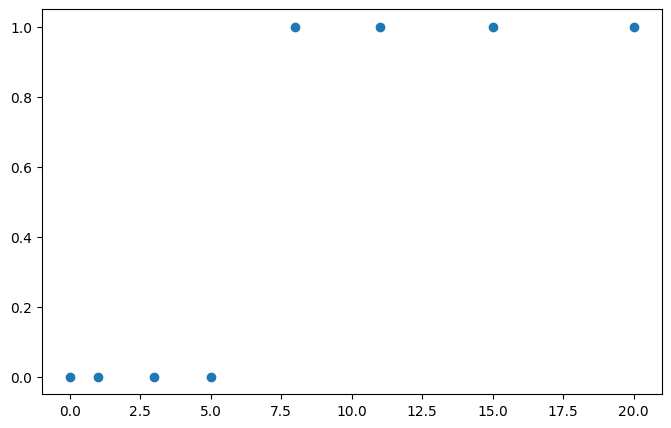

In [10]:
plt.figure(figsize=(8, 5))
plt.scatter(x_train, y_train)

In [11]:
model = nn.Sequential(
    nn.Linear(1, 1),
    nn.Sigmoid()
)

model

Sequential(
  (0): Linear(in_features=1, out_features=1, bias=True)
  (1): Sigmoid()
)

In [12]:
list(model.parameters())

[Parameter containing:
 tensor([[-0.6950]], requires_grad=True),
 Parameter containing:
 tensor([-0.4962], requires_grad=True)]

In [13]:
y_pred = model(x_train)
y_pred

tensor([[3.7844e-01],
        [2.3304e-01],
        [7.0353e-02],
        [1.8499e-02],
        [2.3372e-03],
        [2.9109e-04],
        [1.8061e-05],
        [5.5911e-07]], grad_fn=<SigmoidBackward0>)

In [14]:
3.7844e-01

0.37844

### BCE 손실 함수

Binary Cross Entropy (BCE)는 이진 분류 문제에서 모델이 예측한 확률 분포와 실제 정답 레이블 사이의 차이를 측정하는 손실 함수(Loss Function)입니다. BCE는 예측된 확률 값과 실제 값(0 또는 1) 사이의 차이를 로그 확률로 변환하여 손실을 계산합니다.

<img src='https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2FoslY0%2FbtsLCHawxeG%2FAAAAAAAAAAAAAAAAAAAAAGHwwEFSYt27yqPADmRDoznSpe0WrSCaiLZ08tu_hg0t%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1767193199%26allow_ip%3D%26allow_referer%3D%26signature%3DZjAvWSmY00CKEJQVOn%252Bjekiyo34%253D'>

<img src='https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2FRHljk%2FbtsLC1T532t%2FAAAAAAAAAAAAAAAAAAAAANNo1_hcidkBatvuIvZjoGiegZrbRwDcgJYTOkZyhyzC%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1767193199%26allow_ip%3D%26allow_referer%3D%26signature%3DOE%252BU0ms8Tryr5KShb0NIQiT%252BIig%253D'>

In [15]:
loss = nn.BCELoss()(y_pred, y_train)
loss

tensor(5.0440, grad_fn=<BinaryCrossEntropyBackward0>)

In [16]:
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [17]:
epochs = 1000

In [18]:
for epoch in range(epochs + 1):
    y_pred = model(x_train)
    loss = nn.BCELoss()(y_pred, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f'Epoch: {epoch}/{epochs} Loss: {loss:.6f}')

Epoch: 0/1000 Loss: 5.043980
Epoch: 100/1000 Loss: 0.395748
Epoch: 200/1000 Loss: 0.367399
Epoch: 300/1000 Loss: 0.343098
Epoch: 400/1000 Loss: 0.322116
Epoch: 500/1000 Loss: 0.303868
Epoch: 600/1000 Loss: 0.287886
Epoch: 700/1000 Loss: 0.273790
Epoch: 800/1000 Loss: 0.261278
Epoch: 900/1000 Loss: 0.250103
Epoch: 1000/1000 Loss: 0.240065


In [20]:
list(model.parameters())

[Parameter containing:
 tensor([[0.3519]], requires_grad=True),
 Parameter containing:
 tensor([-1.7598], requires_grad=True)]

In [21]:
x_test = torch.FloatTensor([[7]])
y_pred = model(x_test)
y_pred

tensor([[0.6689]], grad_fn=<SigmoidBackward0>)

In [22]:
y_bool = (y_pred >= 0.5).float()
y_bool

tensor([[1.]])

In [23]:
x_test = torch.FloatTensor([[10]])
y_pred = model(x_test)
y_pred

tensor([[0.8531]], grad_fn=<SigmoidBackward0>)

In [24]:
y_bool = (y_pred >= 0.5).float()
y_bool

tensor([[1.]])

# **3. 다항 논리 회귀**
다항 논리 회귀(Multinomial Logistic Regression)는 종속 변수가 세 개 이상의 범주로 나뉘는 다중 클래스 분류 문제를 해결하는 알고리즘입니다. 예를 들어, 과일의 색깔이 빨강, 노랑, 초록 중 하나로 분류되는 문제에서 사용할 수 있습니다. 이 알고리즘은 각 클래스에 대한 확률을 예측하기 위해 소프트맥스(Softmax) 함수를 사용합니다. 소프트맥스 함수는 각 클래스에 속할 확률을 0과 1 사이의 값으로 변환하며, 모든 클래스의 확률 합이 1이 되도록 정규화합니다. 모델은 입력 데이터가 특정 클래스에 속할 가능성을 계산한 뒤, 가장 높은 확률을 가진 클래스를 최종 예측 값으로 선택합니다. 다항 논리 회귀는 자연어 처리, 이미지 분류, 그리고 다양한 다중 클래스 분류 문제에서 널리 사용됩니다.

In [29]:
x_train = [[1, 2, 1, 1],
           [2, 1, 3, 2],
           [3, 1, 3, 4],
           [4, 2, 5, 5],
           [1, 6, 5, 5],
           [1, 4, 5, 8],
           [1, 7, 7, 7],
           [2, 8, 7, 8],
           [2, 7, 6, 7],
           [2, 6, 6, 6]]

y_train = [0, 0, 0, 1, 1, 1, 2, 2, 2, 2]

In [30]:
x_train = torch.FloatTensor(x_train)
y_train = torch.LongTensor(y_train)
print(x_train.shape)
print(y_train.shape)

torch.Size([10, 4])
torch.Size([10])


In [31]:
model = nn.Sequential(
    nn.Linear(4, 3)
)

model

Sequential(
  (0): Linear(in_features=4, out_features=3, bias=True)
)

<img src='https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2Fbj0BoC%2FbtsLEjsvQxQ%2FAAAAAAAAAAAAAAAAAAAAAO6A6mG0NoM8l2rAF27IOeAYaFNMSOJveYE7JKPNMlSZ%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1767193199%26allow_ip%3D%26allow_referer%3D%26signature%3DnBGffEB6H9x1L4MZYa4fI4lJbnE%253D'>

In [33]:
list(model.parameters())

[Parameter containing:
 tensor([[ 0.1968,  0.0067,  0.4349, -0.0660],
         [ 0.2726,  0.2091,  0.0335,  0.2676],
         [-0.2575,  0.3866, -0.1940, -0.1672]], requires_grad=True),
 Parameter containing:
 tensor([-0.4349,  0.4373, -0.0807], requires_grad=True)]

In [34]:
y_pred = model(x_train)
y_pred

tensor([[ 0.1443,  1.4292,  0.0738],
        [ 1.1382,  1.8273, -1.1255],
        [ 1.2030,  2.6352, -1.7174],
        [ 2.2103,  3.4515, -2.1435],
        [ 1.6468,  3.4698,  0.1757],
        [ 1.4353,  3.8546, -1.0991],
        [ 2.3912,  4.2811, -0.1600],
        [ 2.5288,  5.0304, -0.1981],
        [ 2.1532,  4.5203, -0.2236],
        [ 2.2125,  4.0436, -0.4430]], grad_fn=<AddmmBackward0>)

### CrossEntropyLoss

CrossEntropyLoss는 다중 클래스 분류(Multiclass Classification) 문제에서 모델의 예측과 실제 정답 레이블 간의 차이를 측정하는 손실 함수(Loss Function)입니다. 이 함수는 모델이 예측한 확률 분포와 실제 레이블(정답) 간의 불확실성을 수치화합니다. CrossEntropyLoss는 주로 Softmax 함수와 함께 사용됩니다. Softmax는 각 클래스에 대한 확률 분포를 제공하며, CrossEntropyLoss는 이 확률 분포와 실제 레이블 간의 차이를 계산합니다. 예측이 실제 레이블과 가까울수록 손실 값이 작아지며, 예측이 틀릴수록 손실 값은 커집니다.

<img src='https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2FdDcO2Z%2FbtsLELCjvU7%2FAAAAAAAAAAAAAAAAAAAAAFmLoFsk409JMayNRj-4hVl5mchq4W-Uk2c5quRNUopY%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1767193199%26allow_ip%3D%26allow_referer%3D%26signature%3DXF1Gu40AA60ky%252Bi77Pjhi%252FISZ1g%253D'>

<img src='https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2FcdBQAX%2FbtsLEcf41Mr%2FAAAAAAAAAAAAAAAAAAAAAKGSXZuEiWGbfeK7o-zPOVt6OgvxdzHo4l53VauQQKKB%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1767193199%26allow_ip%3D%26allow_referer%3D%26signature%3Dwt5DYgPPWvyfAQiAURqDSCc7q90%253D'>

In [35]:
loss = nn.CrossEntropyLoss()(y_pred, y_train)
loss

tensor(2.4420, grad_fn=<NllLossBackward0>)

In [36]:
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [37]:
epochs = 10000

In [38]:
for epoch in range(epochs + 1):
    y_pred = model(x_train)
    loss = nn.CrossEntropyLoss()(y_pred, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f'Epoch: {epoch}/{epochs} Loss: {loss: .6f}')

Epoch: 0/10000 Loss:  2.442015
Epoch: 100/10000 Loss:  0.781746
Epoch: 200/10000 Loss:  0.735967
Epoch: 300/10000 Loss:  0.704340
Epoch: 400/10000 Loss:  0.679162
Epoch: 500/10000 Loss:  0.657789
Epoch: 600/10000 Loss:  0.639097
Epoch: 700/10000 Loss:  0.622506
Epoch: 800/10000 Loss:  0.607657
Epoch: 900/10000 Loss:  0.594293
Epoch: 1000/10000 Loss:  0.582213
Epoch: 1100/10000 Loss:  0.571250
Epoch: 1200/10000 Loss:  0.561261
Epoch: 1300/10000 Loss:  0.552124
Epoch: 1400/10000 Loss:  0.543732
Epoch: 1500/10000 Loss:  0.535995
Epoch: 1600/10000 Loss:  0.528834
Epoch: 1700/10000 Loss:  0.522181
Epoch: 1800/10000 Loss:  0.515977
Epoch: 1900/10000 Loss:  0.510172
Epoch: 2000/10000 Loss:  0.504722
Epoch: 2100/10000 Loss:  0.499589
Epoch: 2200/10000 Loss:  0.494740
Epoch: 2300/10000 Loss:  0.490147
Epoch: 2400/10000 Loss:  0.485784
Epoch: 2500/10000 Loss:  0.481631
Epoch: 2600/10000 Loss:  0.477667
Epoch: 2700/10000 Loss:  0.473876
Epoch: 2800/10000 Loss:  0.470243
Epoch: 2900/10000 Loss:  0

In [40]:
x_test = torch.FloatTensor([[2, 7, 7, 7]])
y_pred = model(x_test)
y_pred

tensor([[-5.3657,  5.2433,  6.8465]], grad_fn=<AddmmBackward0>)

In [41]:
y_prob = nn.Softmax(1)(y_pred)
y_prob

tensor([[4.1367e-06, 1.6754e-01, 8.3246e-01]], grad_fn=<SoftmaxBackward0>)

In [45]:
print(f'0일 확률: {y_prob[0][0]:.2f}')
print(f'1일 확률: {y_prob[0][1]:.2f}')
print(f'2일 확률: {y_prob[0][2]:.2f}')

0일 확률: 0.00
1일 확률: 0.17
2일 확률: 0.83


In [46]:
torch.argmax(y_prob, axis=1)

tensor([2])